### first import libraries


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [42]:
# load dataset
egypt_real_estate=pd.read_csv(r"C:\kok\python\egypt_real_estate_listings.csv")

### cleaning data  and save data

In [43]:
# show all data:
egypt_real_estate

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"
...,...,...,...,...,...,...,...,...,...,...,...
19919,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,500,000",Code: 2404\nChalet for sale in North Edge Towe...,"North Edge Towers, New Alamein City, Al Alamei...",Chalet,"1,259 sqft / 117 sqm",2,2,21 Aug 2025,Cash,NaN
19920,https://www.propertyfinder.eg/en/plp/buy/duple...,"24,000,000",Duplex for sale in Eastown -Sodic\n5th settlem...,"Eastown, 5th Settlement Compounds, The 5th Set...",Duplex,"2,756 sqft / 256 sqm",3+ Maid,4,1 Sep 2025,Cash,NaN
19921,https://www.propertyfinder.eg/en/plp/buy/chale...,"3,000,000",Chalet for Sale in One of the Prime Projects o...,"White Sand, Markaz Al Hamam, North Coast",Chalet,"1,195 sqft / 111 sqm",2,2,30 Jul 2025,Cash,NaN
19922,https://www.propertyfinder.eg/en/plp/buy/villa...,"9,500,000",Villa for sale in installments in Sarai Compou...,"Sarai, Mostakbal City Compounds, Mostakbal Cit...",Villa,"2,573 sqft / 239 sqm",5,4,23 Aug 2025,Cash,NaN


In [44]:
# describe the dataset with missing values
egypt_real_estate.describe()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
count,19924,19385,19846,19833,19847,19847,19780,19784,19261,19383,5445
unique,19924,4286,18130,1535,17,683,18,16,353,2,2030
top,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,000,000",Please Note Before Reading:\nThis is one of ma...,"Marassi, Sidi Abdel Rahman, North Coast",Apartment,"1,507 sqft / 140 sqm",3,3,1 Sep 2025,Cash,"100,000 EGP"
freq,1,307,72,433,8355,432,4959,6562,3254,15521,203


In [45]:
# check the data types of each column:
egypt_real_estate.dtypes

url               object
price             object
description       object
location          object
type              object
size              object
bedrooms          object
bathrooms         object
available_from    object
payment_method    object
down_payment      object
dtype: object

In [46]:
# change the data type in culumns to the correct data type:
# price column to float:
clean_price = egypt_real_estate['price'].str.replace(',','',regex=False)
egypt_real_estate['price']=pd.to_numeric(clean_price,errors='coerce').astype(float)
# size colummn to float:
egypt_real_estate['size']= egypt_real_estate['size'].str.replace(r'.*sqft\s*/\s*|\s*sqm','',regex=True,flags=re.IGNORECASE)

clean_size= egypt_real_estate['size'].str.replace(',','',regex=False)
egypt_real_estate['size']=pd.to_numeric(clean_size,errors='coerce').astype(float)
# bedrooms column to int:
temp_bedrooms=egypt_real_estate['bedrooms'].astype(str).str.lower().str.strip()

temp_bedrooms=temp_bedrooms.str.replace('maid','1',regex=False)
def sum_rooms(values):
    if values =='nan' or pd.isna(values) or values=='':
        return np.nan
    elif 'studio' in values:
        return 0.0
    else:
        try:
            return sum(int(x) for x in values.split('+') if x.strip().isdigit())
        except:
            return np.nan
egypt_real_estate['bedrooms']=temp_bedrooms.apply(sum_rooms)
egypt_real_estate['bedrooms']=egypt_real_estate['bedrooms'].astype('Int64')

# bathrooms column to int:
clean_bathrooms=egypt_real_estate['bathrooms'].str.replace('+','',regex=False).str.strip()

egypt_real_estate['bathrooms']=pd.to_numeric(clean_bathrooms,errors='coerce').astype('Int64')

# down_payment column to float:
egypt_real_estate['down_payment']=egypt_real_estate['down_payment'].str.replace(',','',regex=True).str.lower().str.strip()
egypt_real_estate['down_payment']=pd.to_numeric(egypt_real_estate['down_payment'].str.replace('egp','',regex=True),errors='coerce').astype(float)

# available_from column to datetime:
egypt_real_estate['available_from']=pd.to_datetime(egypt_real_estate['available_from'],errors='coerce')

In [47]:
# check the data types of each columns after changing the data types:
egypt_real_estate.dtypes

url                       object
price                    float64
description               object
location                  object
type                      object
size                     float64
bedrooms                   Int64
bathrooms                  Int64
available_from    datetime64[ns]
payment_method            object
down_payment             float64
dtype: object

In [48]:
# the percentage of missing values and count of missing values for each column:
missing_values = egypt_real_estate.isnull().sum()
missing_percentage=(missing_values/egypt_real_estate.shape[0])*100
print("missing_percentage=",missing_percentage)
print("missing_values=",missing_values)

missing_percentage= url                0.000000
price              2.705280
description        0.391488
location           0.456736
type               0.386469
size               0.386469
bedrooms           0.722746
bathrooms          0.727766
available_from     3.327645
payment_method     2.715318
down_payment      72.671150
dtype: float64
missing_values= url                   0
price               539
description          78
location             91
type                 77
size                 77
bedrooms            144
bathrooms           145
available_from      663
payment_method      541
down_payment      14479
dtype: int64


In [49]:
# drop the duplicate rows and fill the missing values with the mean and median and mode and forward for each column :
# drop the duplicate rows:
egypt_real_estate.drop_duplicates(inplace=True)
# fill the missing values:
# fill and fix the missing values in the down_payment column:
def normalize_scale(val, reasonable_max=100):
    if pd.isna(val):
        return np.nan
    while val > reasonable_max:
        val = val / 1000
    return val

egypt_real_estate['down_payment']=egypt_real_estate['down_payment'].apply(normalize_scale)
mean_down_payment=egypt_real_estate['down_payment'].mean()
egypt_real_estate['down_payment']=egypt_real_estate['down_payment'].fillna(mean_down_payment)

# fill the missing values in the size column with the median:
egypt_real_estate['size']=egypt_real_estate['size'].fillna(egypt_real_estate['size'].median())
egypt_real_estate = egypt_real_estate[
    (egypt_real_estate['size'] < 10000) & 
    (egypt_real_estate['size'] >= 10)
].copy()

# fill the missing values in the bedrooms and bathrooms columns with the mode:
egypt_real_estate['bedrooms']=egypt_real_estate['bedrooms'].fillna(egypt_real_estate['bedrooms'].mode()[0])
egypt_real_estate['bathrooms']=egypt_real_estate['bathrooms'].fillna(egypt_real_estate['bathrooms'].mode()[0])
# fill the missing values in the type column with the forward fill:
egypt_real_estate['type']=egypt_real_estate['type'].fillna(egypt_real_estate['type'].ffill())
egypt_real_estate['payment_method']=egypt_real_estate['payment_method'].fillna(egypt_real_estate['payment_method'].bfill())

# fill and fix the missing values in the price column:
egypt_real_estate['price']=egypt_real_estate['price'].apply(lambda x: normalize_scale(x, reasonable_max=1000))
mean_price=egypt_real_estate['price'].mean()
egypt_real_estate['price']=egypt_real_estate['price'].fillna(mean_price)

# fill the missing values in the available_from , location and description columns :
num_missing= egypt_real_estate['available_from'].isnull().sum()
if num_missing > 0 and len(egypt_real_estate['available_from'].dropna()) > 0:
    generated_dates = np.random.choice(egypt_real_estate['available_from'].dropna(), size=num_missing)
    egypt_real_estate.loc[egypt_real_estate['available_from'].isnull(), 'available_from'] = generated_dates

egypt_real_estate['location']=egypt_real_estate['location'].fillna('unknown')
egypt_real_estate['description']=egypt_real_estate['description'].fillna('no mentioned')

In [50]:
# check the missing values after filling the missing values:
missing_values = egypt_real_estate.isnull().sum()
missing_values


url               0
price             0
description       0
location          0
type              0
size              0
bedrooms          0
bathrooms         0
available_from    0
payment_method    0
down_payment      0
dtype: int64

In [51]:
# rename name of the columns:
egypt_real_estate.rename(columns={'price':'price_by_million_EGP','size':'size_by_sqm','down_payment':'down_payment_by_million_EGP'}, inplace=True)

In [52]:
# show all the data after cleaning and filling the missing values:
egypt_real_estate

,url,price_by_million_EGP,description,location,type,size_by_sqm,bedrooms,bathrooms,available_from,payment_method,down_payment_by_million_EGP
0,https://www.propertyfinder.eg/en/plp/buy/chale...,8.000,OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,68.0,2,1,2025-08-31,Cash,1.200000
1,https://www.propertyfinder.eg/en/plp/buy/villa...,25.000,"For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,220.0,4,4,2025-09-02,Cash,2.100000
2,https://www.propertyfinder.eg/en/plp/buy/chale...,15.135,"With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,118.0,2,2,2025-08-19,Cash,1.513000
3,https://www.propertyfinder.eg/en/plp/buy/apart...,12.652,Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,166.0,3,2,2025-08-26,Installments,1.260000
4,https://www.propertyfinder.eg/en/plp/buy/villa...,45.250,Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,400.0,7,7,2025-09-02,Cash,2.262500
...,...,...,...,...,...,...,...,...,...,...,...
19919,https://www.propertyfinder.eg/en/plp/buy/chale...,10.500,Code: 2404\nChalet for sale in North Edge Towe...,"North Edge Towers, New Alamein City, Al Alamei...",Chalet,117.0,2,2,2025-08-21,Cash,6.546943
19920,https://www.propertyfinder.eg/en/plp/buy/duple...,24.000,Duplex for sale in Eastown -Sodic\n5th settlem...,"Eastown, 5th Settlement Compounds, The 5th Set...",Duplex,256.0,4,4,2025-09-01,Cash,6.546943
19921,https://www.propertyfinder.eg/en/plp/buy/chale...,3.000,Chalet for Sale in One of the Prime Projects o...,"White Sand, Markaz Al Hamam, North Coast",Chalet,111.0,2,2,2025-07-30,Cash,6.546943
19922,https://www.propertyfinder.eg/en/plp/buy/villa...,9.500,Villa for sale in installments in Sarai Compou...,"Sarai, Mostakbal City Compounds, Mostakbal Cit...",Villa,239.0,5,4,2025-08-23,Cash,6.546943


In [53]:
# describe the dataset after cleaning data
egypt_real_estate.describe()

,price_by_million_EGP,size_by_sqm,bedrooms,bathrooms,available_from,down_payment_by_million_EGP
count,19917.000000,19917.000000,19917.0,19917.0,19917,19917.000000
mean,20.309297,215.261535,3.443641,2.953356,2025-08-21 10:24:36.005422592,6.546991
min,1.010000,20.000000,0.0,1.0,2023-06-14 00:00:00,0.104000
25%,6.100000,127.000000,3.0,2.0,2025-08-19 00:00:00,6.546943
50%,10.850000,170.000000,3.0,3.0,2025-08-31 00:00:00,6.546943
75%,19.974000,240.000000,4.0,4.0,2025-09-01 00:00:00,6.546943
max,1000.000000,9500.000000,8.0,7.0,2027-10-31 00:00:00,100.000000
std,59.431151,201.890716,1.376319,1.285935,NaN,10.311354


In [54]:
# to save data after cleaned data:
egypt_real_estate.to_csv('egypt_real_estate_clean.csv', index=False)

### data visualization

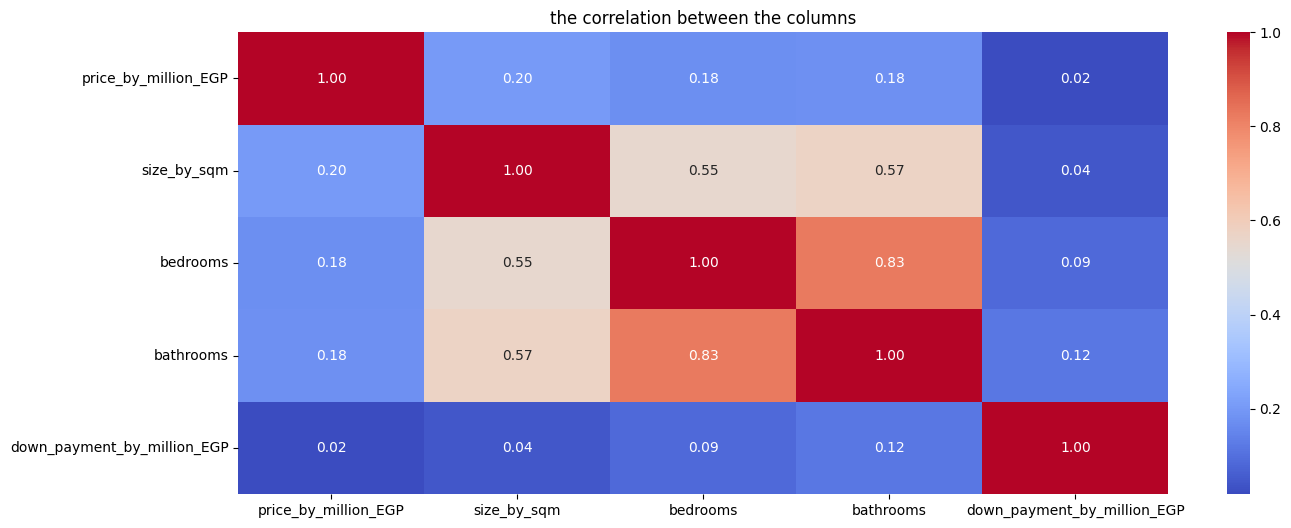

In [55]:
# create heapmap to show the correlation between the columns:
plt.figure(figsize=(15,6))
plt.title("the correlation between the columns")
sns.heatmap(egypt_real_estate.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')
plt.show()


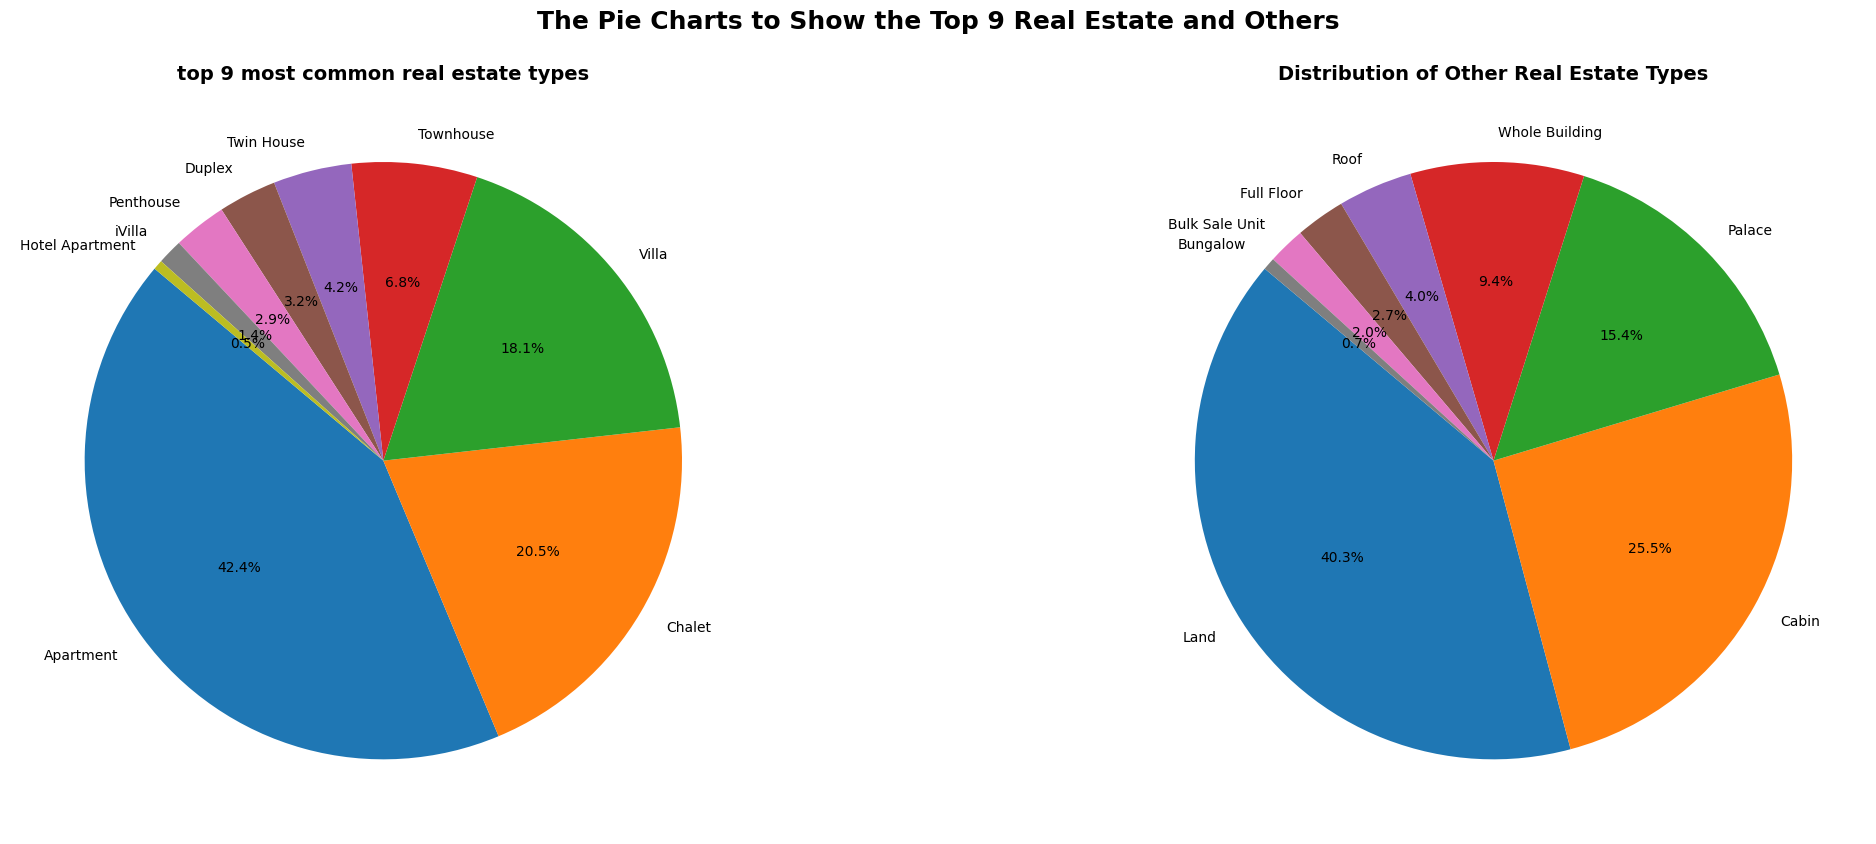

In [56]:
#create the pie chart to show whose the most common type of real estate in the dataset:
all_counts_types= egypt_real_estate['type'].value_counts()

top_9= all_counts_types.head(9)

other_counts= all_counts_types.iloc[9:]

fig ,(ax1,ax2)=plt.subplots(1,2,figsize=(25,8))

ax1.pie(top_9, autopct='%1.1f%%', labels=top_9.index, startangle=140)

ax1.set_title("top 9 most common real estate types", fontsize=14 , fontweight='bold')

ax2.pie(other_counts, autopct='%1.1f%%',labels=other_counts.index, startangle=140)

ax2.set_title("Distribution of Other Real Estate Types" , fontsize=14, fontweight='bold')

plt.tight_layout()
fig.suptitle("The Pie Charts to Show the Top 9 Real Estate and Others", fontsize=18, fontweight='bold', y=1.05)
plt.show()

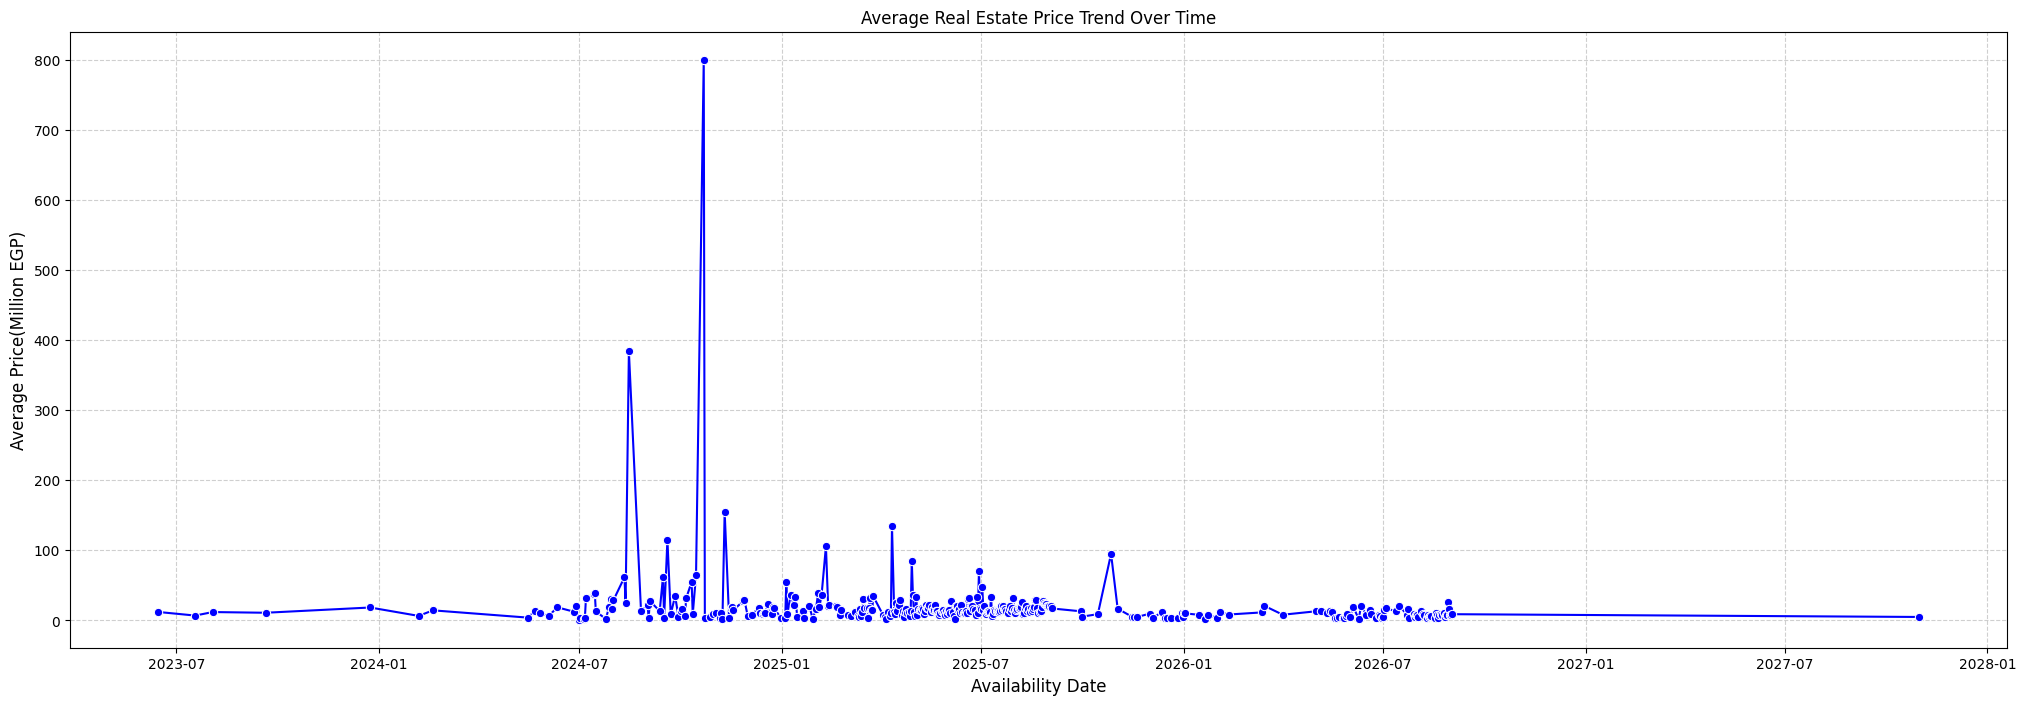

In [57]:
# create the line char to show Average Real Estate Price Trend Over Time:
price_tend= egypt_real_estate.groupby('available_from')['price_by_million_EGP'].mean().reset_index()

plt.figure(figsize=(25,8))

sns.lineplot(data=price_tend,x='available_from', y='price_by_million_EGP', marker='o', color='b')

plt.title("Average Real Estate Price Trend Over Time")

plt.xlabel("Availability Date", fontsize=12)

plt.ylabel("Average Price(Million EGP)", fontsize=12)

plt.grid(True, linestyle='--',alpha=0.6)

plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_20952\3157111671.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=egypt_real_estate , x='type' , y='price_by_million_EGP' , order=type_order , palette='Blues_r')


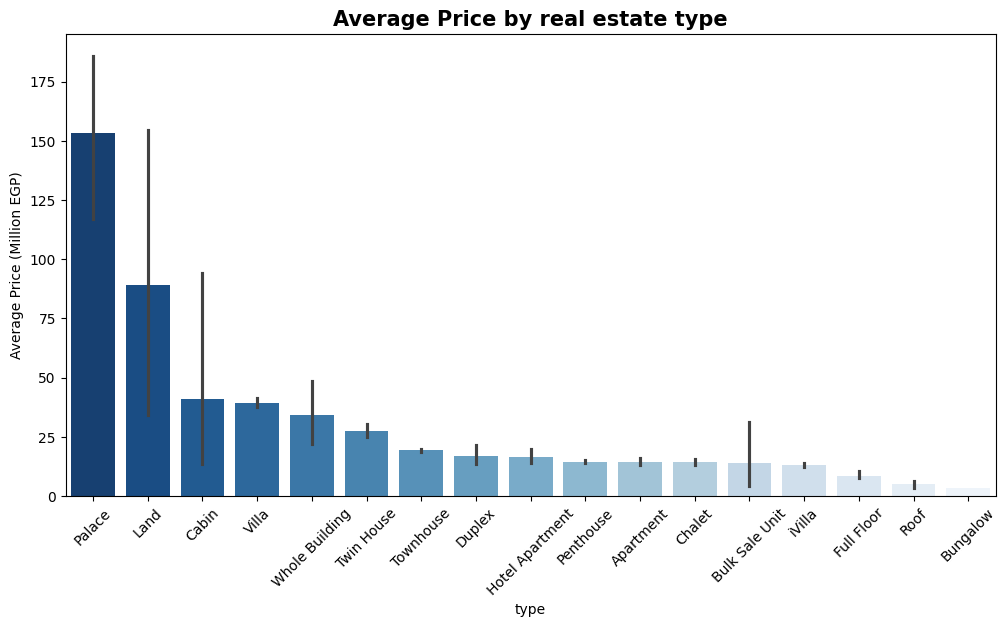

In [58]:
# create barplot Average Price by real estate type:

plt.figure(figsize=(12,6))

type_order= egypt_real_estate.groupby('type')['price_by_million_EGP'].mean().sort_values(ascending=False).index

sns.barplot(data=egypt_real_estate , x='type' , y='price_by_million_EGP' , order=type_order , palette='Blues_r')

plt.title("Average Price by real estate type" , fontsize=15 , fontweight='bold')

plt.xticks(rotation=45)

plt.ylabel("Average Price (Million EGP)")

plt.show()

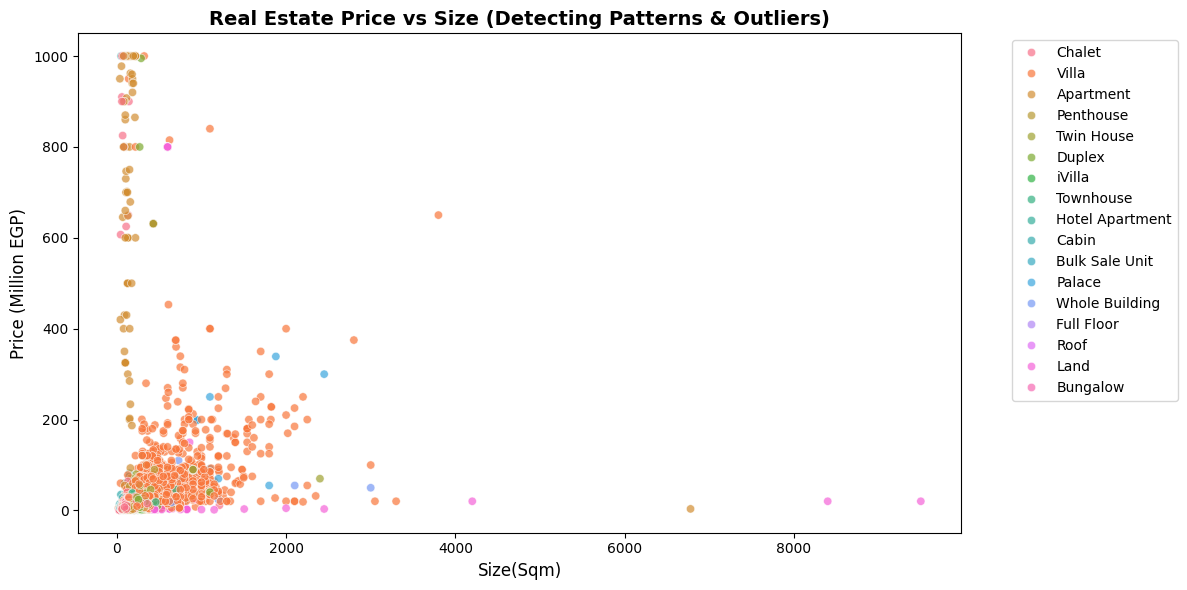

In [59]:
# create scatter plot to Real Estate Price vs Size (Detecting Patterns & Outliers):
plt.figure(figsize=(12,6))

sns.scatterplot( data=egypt_real_estate , x='size_by_sqm' , y='price_by_million_EGP', hue='type', alpha=0.7)

plt.title("Real Estate Price vs Size (Detecting Patterns & Outliers)", fontsize=14 ,fontweight='bold')

plt.xlabel("Size(Sqm)",fontsize=12)
plt.ylabel("Price (Million EGP)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')

plt.tight_layout()
plt.show()

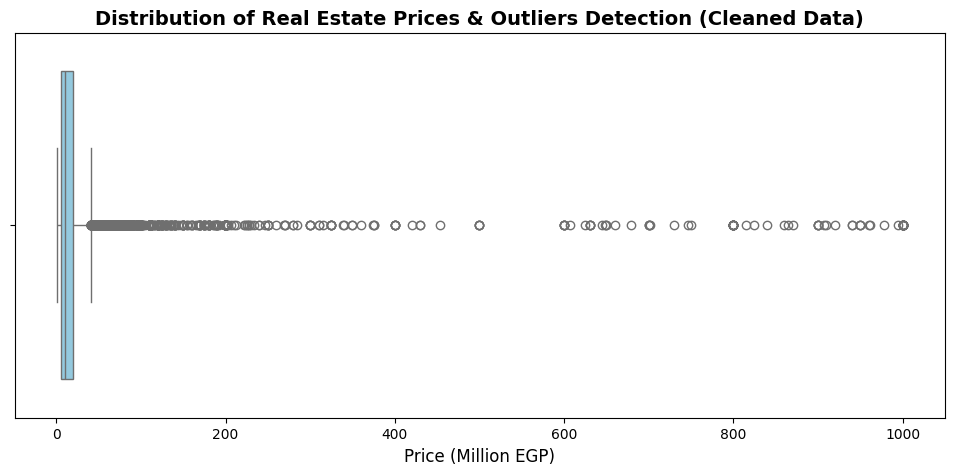

In [60]:
# create box plot Distribution of Real Estate Prices & Outliers Detection (Cleaned Data):

plt.figure(figsize=(12, 5))


sns.boxplot(data=egypt_real_estate, x='price_by_million_EGP', color='skyblue')

plt.title("Distribution of Real Estate Prices & Outliers Detection (Cleaned Data)", fontsize=14, fontweight='bold')
plt.xlabel("Price (Million EGP)", fontsize=12)

plt.show()

### end project
